# Lab 2: Sentinel-1 GRD Processing Pipeline, Geometry, and Terrain Effects

This notebook is designed to pair with a small amount of preprocessing in SNAP and keep the analysis, interpretation, and documentation in Jupyter.

## Lab objective
Build intuition for what a GRD preprocessing chain does, and why mountainous terrain strongly affects SAR appearance.

By the end of this lab, students should be able to:

- describe the major GRD preprocessing steps,
- compare a less-processed image to a terrain-corrected image,
- identify layover, shadow, and foreshortening,
- relate these distortions to topography and radar look geometry,
- explain why terrain correction changes both the geometry and the interpretation of the image.

---

## Recommended study area

A mountainous area is the right choice, as steep topography has the greatest impact on SAR geometry. I chose the Dolomites because there is steep relief, exposed slopes and valleys, some built up area or agricultural valley floor, and limited glacial coverage.

### Why not mid-winter?
Snow does not make the geometry lesson impossible, but it adds extra variability in backscatter and can make interpretation less clean for a first terrain lab.

### SNAP
Use SNAP for the preprocessing-heavy steps:
1. Read Sentinel-1 GRD scene
2. Apply orbit file
3. Radiometric calibration
4. Terrain correction
5. subset the image to a smaller AOI (full GRD scenes are ~1.5Gb, exported GeoTIFF's are on the order of 3.5 Gb, so unless you have a lot of RAM/VRAM, enough to hold all GeoTIFF's, processing will be very slow). I will provide 
6. Export outputs as GeoTIFF, both before and after terrain correction, as well as DEM, incidence angle, and shadow/layover/foreshortening mask.

### Jupyter notebook
Use this notebook for:
- loading the exported rasters,
- plotting comparisons,
- overlaying DEM and masks,
- computing histograms and transects,
- answering interpretation questions.


## SNAP workflow

We will all start in SNAP for preprocessing, but I will provide the subsetted GeoTIFF files that will be used in this notebook.

For a single GRD scene:

1. **Read** Sentinel-1 GRD
2. **Apply Orbit File**
3. **Calibration** → sigma0
4. **Terrain Correction** (Range-Doppler)
5. Export:
   - a less-processed calibrated image (before terrain correction),
   - a terrain-corrected image,
   - DEM 
   - Incidence Angle
   - Shadow and Layover mask

**QUESTION (10pts): Investigate the metadata for the GRD file downloaded from ESA. Is this scene full resolution? Give the metadata field(s) that support your answer.**

**ANSWER:** 

**QUESTION (10pts): What is the line of sight angle at the near range of the scene and at the far range of the scene? Which edge of the scene (east/west) will be more susceptible to foreshortening/layover effects, and which edge of the scene will be more susceptible to shadow effects?**

**ANSWER:** 

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pandas as pd


## 1. Set file paths

Edit the paths below to point to your exported raster files.

In [2]:
data_dir = Path(r"C:\Users\USER\Desktop\Radar Lab\Lab2")

pre_tc_path = data_dir / "pre_TC_VV_subset.tif"
post_tc_path = data_dir / "post_TC_VV_subset.tif"
dem_path = data_dir / "dem_subset.tif"
layover_shadow_path = data_dir / "layover_shadow_mask_subset.tif"
incidence_angle_path = data_dir / "incidence_angle_subset.tif"

print("Expected files:")
for p in [pre_tc_path, post_tc_path, dem_path, layover_shadow_path, incidence_angle_path]:
    print(p)


Expected files:
C:\Users\USER\Desktop\Radar Lab\Lab2\pre_TC_VV_subset.tif
C:\Users\USER\Desktop\Radar Lab\Lab2\post_TC_VV_subset.tif
C:\Users\USER\Desktop\Radar Lab\Lab2\dem_subset.tif
C:\Users\USER\Desktop\Radar Lab\Lab2\layover_shadow_mask_subset.tif
C:\Users\USER\Desktop\Radar Lab\Lab2\incidence_angle_subset.tif


## 2. Helper functions

These functions keep the notebook readable and reduce repeated plotting code.


In [3]:
def read_raster(path, band=1):
    """Read a single-band raster and return array + metadata.
    Nodata values are converted to NaN.
    """
    with rasterio.open(path) as src:
        arr = src.read(band).astype("float32")
        meta = src.meta.copy()
        bounds = src.bounds
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, meta, bounds, transform, crs


def plot_image(arr, title="", vmin=None, vmax=None, cmap="gray", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_side_by_side(arr1, arr2, title1, title2, vmin=None, vmax=None, cmap="gray", figsize=(14, 6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(arr1, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(title1)
    axes[0].axis("off")

    im2 = axes[1].imshow(arr2, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(title2)
    axes[1].axis("off")

    fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.8)
    plt.show()


def to_db(arr, eps=1e-6):
    """Convert linear power to dB if needed.
    If your exported rasters are already in dB, do not apply this.
    """
    return 10 * np.log10(np.maximum(arr, eps))


def robust_limits(arr, pmin=2, pmax=98):
    valid = arr[np.isfinite(arr)]
    return np.percentile(valid, pmin), np.percentile(valid, pmax)


def histogram(arr, bins=100, title="", xlabel="", logy=False):
    valid = arr[np.isfinite(arr)]
    plt.figure(figsize=(8, 4))
    plt.hist(valid, bins=bins)
    if logy:
        plt.yscale("log")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Pixel count")
    plt.grid(True, alpha=0.3)
    plt.xlim(xmin=0,xmax=200)
    plt.show()

def plot_transects(arr1, arr2, label1="Before TC", label2="After TC", axis=0, title="Central transect"):
    t1 = central_transect(arr1, axis=axis)
    t2 = central_transect(arr2, axis=axis)

    plt.figure(figsize=(10, 4))
    plt.plot(t1, label=label1)
    plt.plot(t2, label=label2)
    plt.title(title)
    plt.xlabel("Pixel index")
    plt.ylabel("Backscatter")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def pick_points(image, title="Click 2 points, then close the figure", cmap="gray", vmin=None, vmax=None):
    """Display an image and let the user click two points.

    Returns:
        pts: list of two (x, y) integer pixel tuples
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")

    pts = plt.ginput(2, timeout=-1)
    plt.close(fig)

    pts = [(int(round(x)), int(round(y))) for x, y in pts]
    return pts


def extract_transect(arr, p0, p1, n=500):
    """Extract values along a line between two pixel coordinates."""
    x0, y0 = p0
    x1, y1 = p1

    xs = np.linspace(x0, x1, n)
    ys = np.linspace(y0, y1, n)

    xs_i = np.clip(np.round(xs).astype(int), 0, arr.shape[1] - 1)
    ys_i = np.clip(np.round(ys).astype(int), 0, arr.shape[0] - 1)

    values = arr[ys_i, xs_i]
    distance = np.arange(n)

    return distance, values, xs_i, ys_i


def plot_transect_on_image(image, p0, p1, title="", cmap="gray", vmin=None, vmax=None):
    """Plot an image with the selected transect overlaid."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], 'r-', linewidth=2)
    ax.plot(p0[0], p0[1], 'go', markersize=8, label='Start')
    ax.plot(p1[0], p1[1], 'bo', markersize=8, label='End')
    ax.set_title(title)
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    ax.legend()
    plt.show()


def robust_limits(arr, pmin=2, pmax=98):
    valid = arr[np.isfinite(arr)]
    return np.percentile(valid, pmin), np.percentile(valid, pmax)


## 3. Load the rasters

This section reads the less-processed image, terrain-corrected image, and terrain corrected associated files.


In [4]:
pre_tc, pre_meta, pre_bounds, pre_transform, pre_crs = read_raster(pre_tc_path)
post_tc, post_meta, post_bounds, post_transform, post_crs = read_raster(post_tc_path)
dem, dem_meta, dem_bounds, dem_transform, dem_crs = read_raster(dem_path)

print("Pre-TC shape:", pre_tc.shape, "| CRS:", pre_crs)
print("Post-TC shape:", post_tc.shape, "| CRS:", post_crs)
print("DEM shape:", dem.shape, "| CRS:", dem_crs)


C:\Users\USER\miniconda3\envs\gee-s1\Lib\site-packages\rasterio\__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Pre-TC shape: (4328, 2530) | CRS: None
Post-TC shape: (5010, 2784) | CRS: EPSG:4326
DEM shape: (5010, 2784) | CRS: EPSG:4326


**QUESTION (10pts): Why is the CRS (coordinate reference system) for the Pre-TC view "None" while the post-TC has "EPSG:4326"?**

**ANSWER:**


**QUESTION (10pts): Why can't we overlay the Pre-TC image with the DEM? Give two reasons.**

**ANSWER:**



## 4. Quick inspection of value ranges

This is a good sanity check before plotting.


In [5]:
summary = pd.DataFrame({
    "dataset": ["pre_tc", "post_tc", "dem"],
    "min": [np.nanmin(pre_tc), np.nanmin(post_tc), np.nanmin(dem)],
    "max": [np.nanmax(pre_tc), np.nanmax(post_tc), np.nanmax(dem)],
    "mean": [np.nanmean(pre_tc), np.nanmean(post_tc), np.nanmean(dem)],
    "std": [np.nanstd(pre_tc), np.nanstd(post_tc), np.nanstd(dem)],
})
summary


,dataset,min,max,mean,std
0,pre_tc,0.000113,187.726318,0.151583,0.333453
1,post_tc,0.000488,87.629219,0.258735,0.485669
2,dem,149.975311,2504.820312,1102.638062,566.438904


## 5. Visualize the pre- and post-terrain-correction images

This is the first key comparison.

Please compare the pre- and post- terrain corrected images carefully.
- Where are slopes compressed or stretched?
- Which bright areas shift location after terrain correction?
- Do valleys and ridges line up better with the DEM after terrain correction?

**QUESTION (10pts): In SNAP, using the post-TC VV image, find pixels that exhibit: (1) layover, (2) foreshortening, and (3) shadow. You can use the full image instead of the subsetted image. Foreshortening and layover can appear very similarly in the maps below. I suggest examining the incidence angle map carefully (this will be easiest in SNAP or another geoTIFF viewer). To make layover locations easier to find, remember how the incidence angle varies in range over the scene. To answer this question, right click on a pixel in the image window, and click "Copy pixel-info to clipboard" and paste the result below. Remember, Layover is value 1, and shadow is value 2.** 

**ANSWER:**


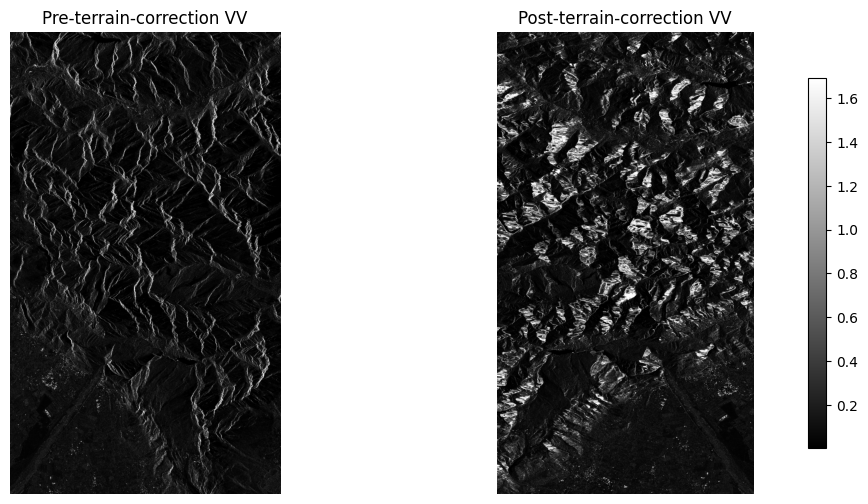

In [6]:
vmin_pre, vmax_pre = robust_limits(pre_tc)
vmin_post, vmax_post = robust_limits(post_tc)
vmin = min(vmin_pre, vmin_post)
vmax = max(vmax_pre, vmax_post)

plot_side_by_side(
    pre_tc, post_tc,
    "Pre-terrain-correction VV",
    "Post-terrain-correction VV",
    vmin=vmin, vmax=vmax, cmap="gray"
)


## 6. Visualize the DEM

Use the DEM to connect image distortions to terrain.

Things to look at:
- Are steep radar-facing slopes unusually bright?
- Are some dark zones likely radar shadow rather than just low backscatter land cover?


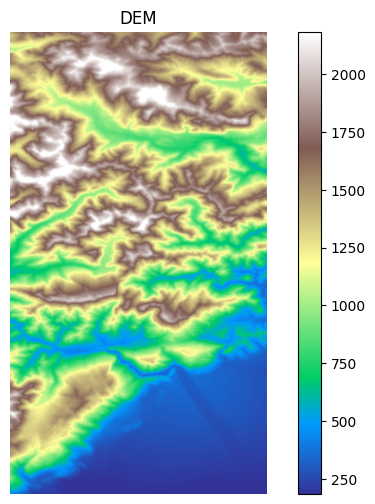

In [7]:
dem_vmin, dem_vmax = robust_limits(dem, 1, 99)
plot_image(dem, title="DEM", vmin=dem_vmin, vmax=dem_vmax, cmap="terrain")


## 7. Histograms before and after terrain correction

A histogram is a blunt but useful summary. It can show whether the distribution shifts after terrain correction.

**QUESTION (10pts): How did the distribution of backscatter change after terrain correction? Explain why.**

**ANSWER:** 

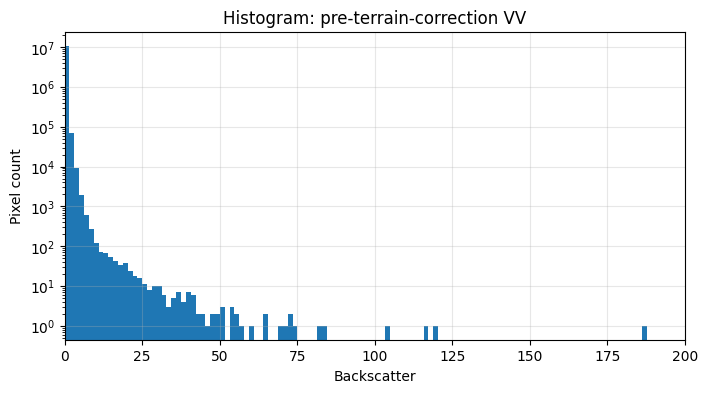

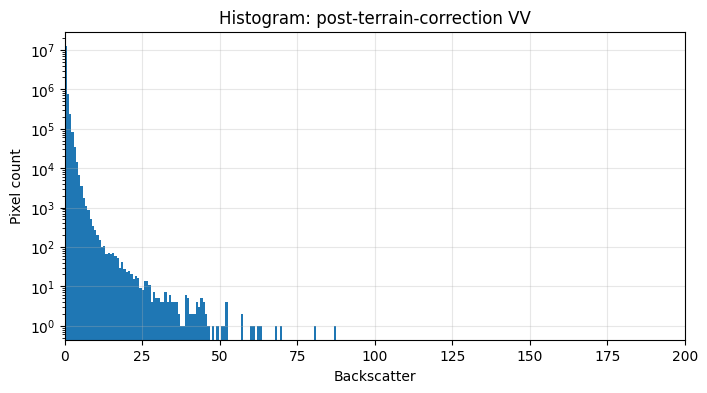

In [8]:
histogram(pre_tc, bins=120, title="Histogram: pre-terrain-correction VV", xlabel="Backscatter", logy=True)
histogram(post_tc, bins=120, title="Histogram: post-terrain-correction VV", xlabel="Backscatter", logy=True)

## 9. Plot the layover/shadow mask exported from SNAP


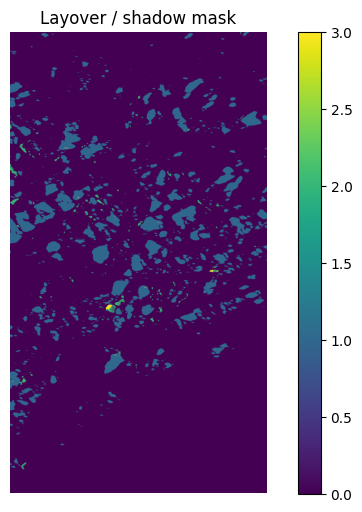

In [9]:
if layover_shadow_path.exists():
    layover_shadow, ls_meta, ls_bounds, ls_transform, ls_crs = read_raster(layover_shadow_path)
    plot_image(layover_shadow, title="Layover / shadow mask", cmap="viridis")
else:
    print("No layover/shadow mask file found. Please add the file.")


## 10. Incidence angle

If you exported an incidence-angle raster, this is a good place to inspect it and compare it with brightness.

**QUESTION (10pts): Where are bright/dark patterns linked to local geometry rather, and where are bright/dark patterns linked to land cover.**

**ANSWER:**


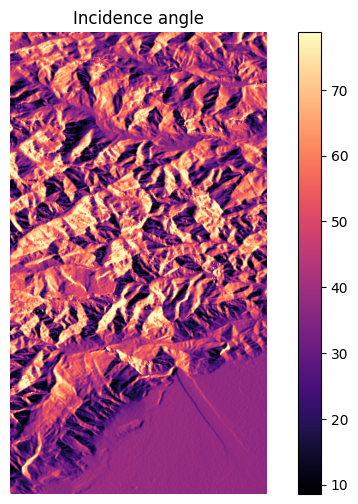

In [10]:
if incidence_angle_path.exists():
    incidence, inc_meta, inc_bounds, inc_transform, inc_crs = read_raster(incidence_angle_path)
    inc_vmin, inc_vmax = robust_limits(incidence)
    plot_image(incidence, title="Incidence angle", vmin=inc_vmin, vmax=inc_vmax, cmap="magma")
else:
    print("No incidence angle file found. Please add the file.")


## 11. Plot a specific transect.

Next, I want you to attempt to plot the same transect on the pre- and post- terrrain corrected images. First, run these blocks of code to plot my transect on the maps below, and then the next two blocks of code to plot the transect values. Take a moment to think about what these transects are showing: how do the backscatter values change, and how is the layover/shadow mask related to topography.

**QUESTION (10pts): See paragraph below**
Next, I want you to change the transects so that they run east-west instead of north-south. To do this, select a start and end point corresponding to the same geographic feature on both images. I have provided a transect that runs roughly north-south, and I did this by selecting the same-ish pixels in both images (I used the edges of two lakes visible in the radar image). Your task is to change this so that the transect runs east-west. I also found it easier to slect specific pixels in SNAP. To do so, open the GeoTIFF-s of the subset images in SNAP, and find the appropriate x,y pixels for the start and end points in both the pre-TC and post-TC image.

**QUESTION (10pts): Which transects, the north-south ones or the east-west ones, best show the effects of radar geometry and terrain correction, and why?**

**ANSWER:**

In [11]:
pts_pre = [(368, 3419), (983, 87)]
pts_post = [(2468, 4028), (2288, 567)]

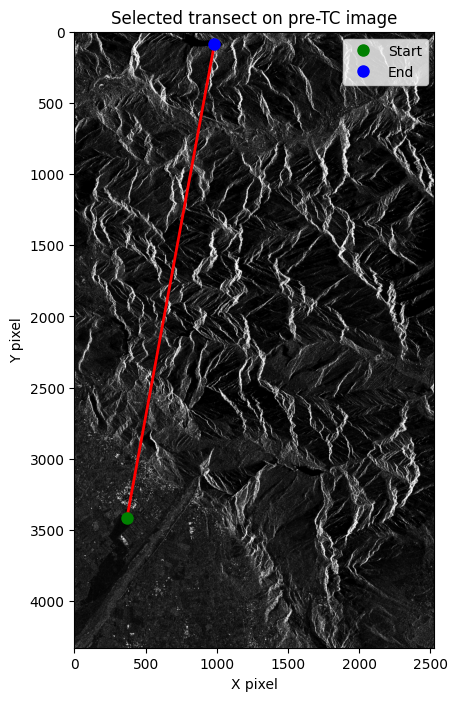

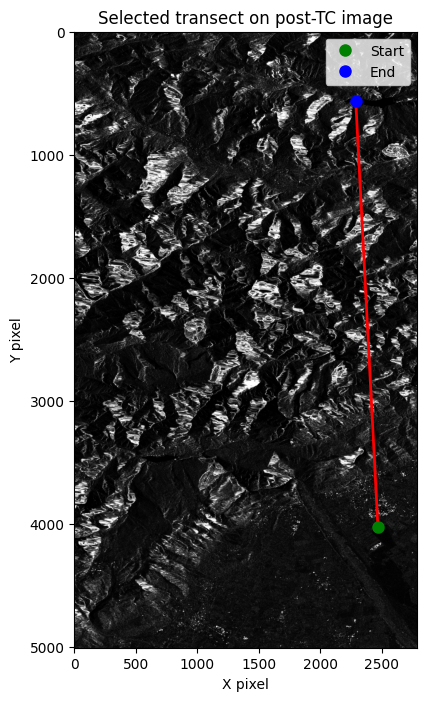

In [12]:
# Choose display ranges
pre_vmin, pre_vmax = robust_limits(pre_tc)
post_vmin, post_vmax = robust_limits(post_tc)

plot_transect_on_image(
    pre_tc, pts_pre[0], pts_pre[1],
    title="Selected transect on pre-TC image",
    cmap="gray", vmin=pre_vmin, vmax=pre_vmax
)

plot_transect_on_image(
    post_tc, pts_post[0], pts_post[1],
    title="Selected transect on post-TC image",
    cmap="gray", vmin=post_vmin, vmax=post_vmax
)


Once you have the transect locations ploted, run the following code blocks to plot the transect values, DEM, and layover/shadow mask values.

In [13]:
dist_pre, vals_pre, _, _ = extract_transect(pre_tc, pts_pre[0], pts_pre[1])
dist_post, vals_post, _, _ = extract_transect(post_tc, pts_post[0], pts_post[1])
dist_dem, vals_dem, _, _ = extract_transect(dem, pts_post[0], pts_post[1])

has_mask = 'layover_shadow' in globals()

if has_mask:
    dist_mask, vals_mask, _, _ = extract_transect(layover_shadow, pts_post[0], pts_post[1])
else:
    print("No layover_shadow array found; skipping mask transect.")

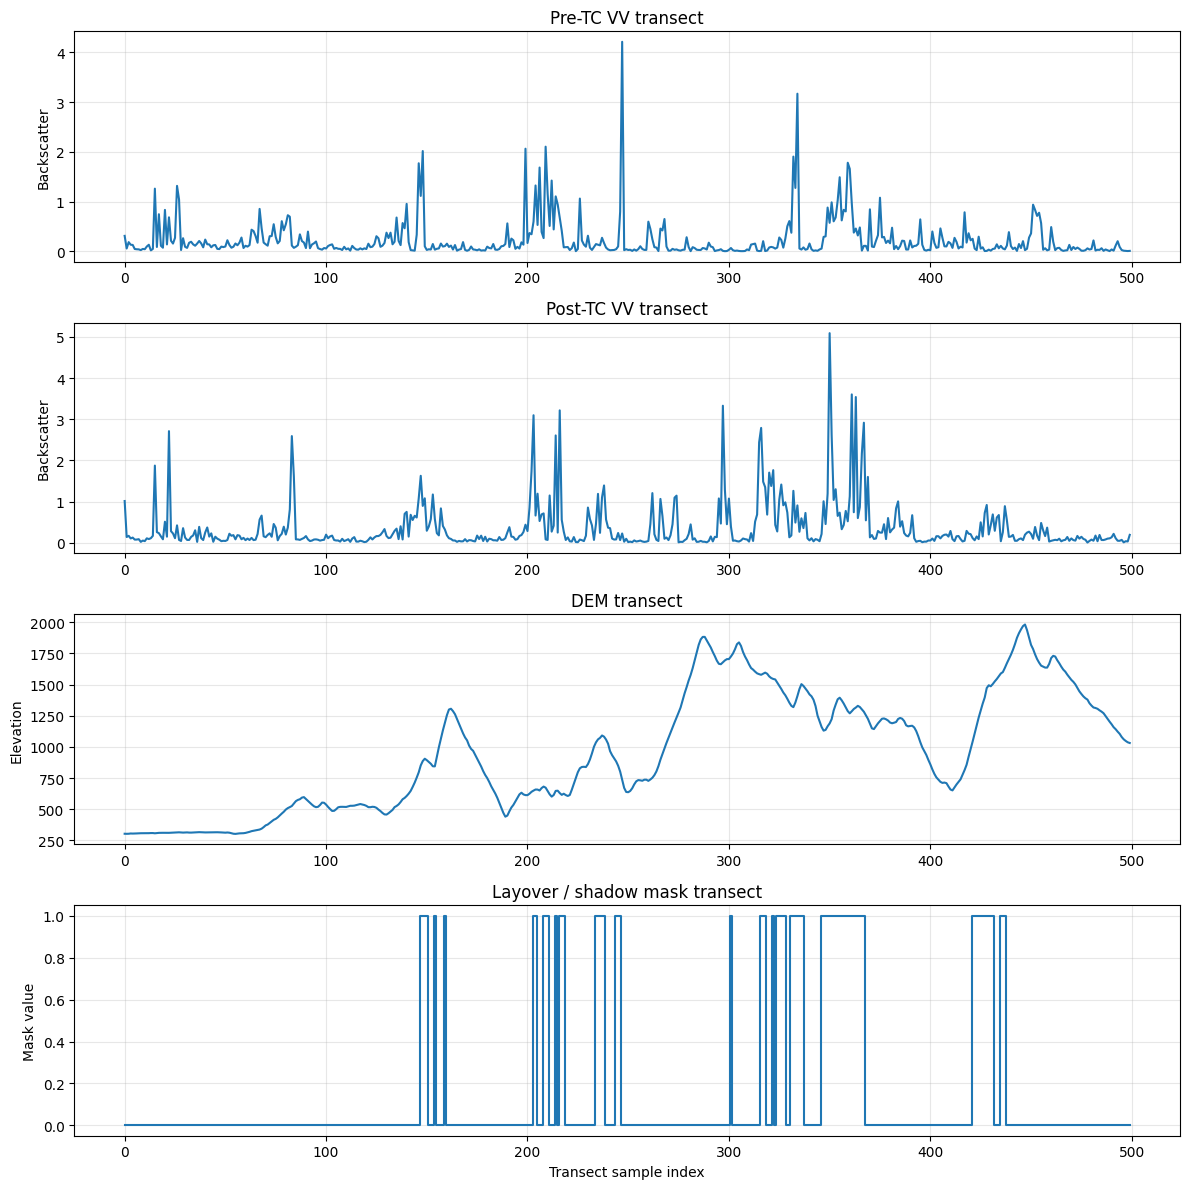

In [14]:
n_panels = 4 if has_mask else 3
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels), sharex=False)

axes[0].plot(dist_pre, vals_pre)
axes[0].set_title("Pre-TC VV transect")
axes[0].set_ylabel("Backscatter")
axes[0].grid(True, alpha=0.3)

axes[1].plot(dist_post, vals_post)
axes[1].set_title("Post-TC VV transect")
axes[1].set_ylabel("Backscatter")
axes[1].grid(True, alpha=0.3)

axes[2].plot(dist_dem, vals_dem)
axes[2].set_title("DEM transect")
axes[2].set_ylabel("Elevation")
axes[2].grid(True, alpha=0.3)

if has_mask:
    axes[3].step(dist_mask, vals_mask, where="mid")
    axes[3].set_title("Layover / shadow mask transect")
    axes[3].set_ylabel("Mask value")
    axes[3].set_xlabel("Transect sample index")
    axes[3].grid(True, alpha=0.3)
else:
    axes[2].set_xlabel("Transect sample index")

plt.tight_layout()
plt.show()


## Reflection question

**QUESTION (10pts): If a researcher downloaded a ready-made GRD product and never thought about terrain effects, what kinds of interpretation errors might they make in a mountainous study area?**

**ANSWER:**

## In this section, I was just exploring the layover/shadow mask file.

In particular looking at the distribution of layover, shadow, or both. Nothing to do here, just some additional information.

All values are integer-like: True

Unique values and counts:
Value 0: 12621438 pixels
Value 1: 1265193 pixels
Value 2: 57384 pixels
Value 3: 3825 pixels


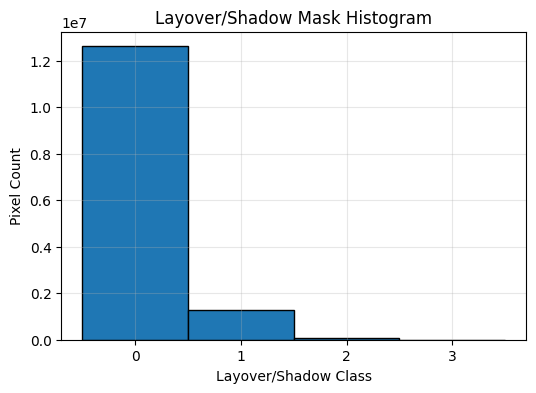

In [15]:
# Remove NaNs if present
valid = layover_shadow[np.isfinite(layover_shadow)]

# --- 1. Check if values are integers ---
is_integer = np.allclose(valid, np.round(valid))
print(f"All values are integer-like: {is_integer}")

# --- 2. Unique values and counts ---
unique_vals, counts = np.unique(valid, return_counts=True)

print("\nUnique values and counts:")
for v, c in zip(unique_vals, counts):
    print(f"Value {int(v)}: {c} pixels")

# --- 3. Histogram (discrete bins) ---
bins = np.arange(valid.min(), valid.max() + 2) - 0.5

plt.figure(figsize=(6,4))
plt.hist(valid, bins=bins, edgecolor='black')
plt.xticks(unique_vals)
plt.xlabel("Layover/Shadow Class")
plt.ylabel("Pixel Count")
plt.title("Layover/Shadow Mask Histogram")
plt.grid(True, alpha=0.3)
plt.show()